In [185]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
from src.utils.extract_data import get_data
# Download latest version
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "selener/consumer-complaint-database", "rows.csv")
print("Path to dataset files:", df.head())

Path to dataset files:   Date received                                            Product  \
0    05/10/2019                        Checking or savings account   
1    05/10/2019                        Checking or savings account   
2    05/10/2019                                    Debt collection   
3    05/10/2019  Credit reporting, credit repair services, or o...   
4    05/10/2019                        Checking or savings account   

                        Sub-product                                 Issue  \
0                  Checking account                   Managing an account   
1  Other banking product or service                   Managing an account   
2                  Payday loan debt                 Communication tactics   
3                  Credit reporting  Incorrect information on your report   
4                  Checking account                   Managing an account   

                                      Sub-issue Consumer complaint narrative  \
0            

In [54]:
# # Install dependencies as needed:
# # pip install kagglehub[pandas-datasets]
# import kagglehub
# from kagglehub import KaggleDatasetAdapter
#
# # Set the path to the file you'd like to load
# file_path = "rows.csv"
#
# # Load the latest version
# df = kagglehub.dataset_load(
#   KaggleDatasetAdapter.PANDAS,
#   "selener/consumer-complaint-database",
#   file_path,
#   # Provide any additional arguments like
#   # sql_query or pandas_kwargs. See the
#   # documenation for more information:
#   # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
# )

In [186]:
print("First 5 records:", df.head())
print(df.dtypes)

First 5 records:   Date received                                            Product  \
0    05/10/2019                        Checking or savings account   
1    05/10/2019                        Checking or savings account   
2    05/10/2019                                    Debt collection   
3    05/10/2019  Credit reporting, credit repair services, or o...   
4    05/10/2019                        Checking or savings account   

                        Sub-product                                 Issue  \
0                  Checking account                   Managing an account   
1  Other banking product or service                   Managing an account   
2                  Payday loan debt                 Communication tactics   
3                  Credit reporting  Incorrect information on your report   
4                  Checking account                   Managing an account   

                                      Sub-issue Consumer complaint narrative  \
0             Probl

In [206]:
df['Date received'] = pd.to_datetime(df['Date received'])
df['Year'] = df['Date received'].dt.year
df['QtTickets'] = 1  # uma linha == 1 ticket
print(df['QtTickets'].count())

1282355


In [210]:
top_n = 10
top_companies = (company_time.groupby('Company', as_index=False)
                           .agg(Total=('TotalTickets', 'sum'))
                           .nlargest(top_n, 'Total')['Company'])
print(top_companies)
qtd_entry_year = df.groupby('Year').size().reset_index(name='TotalTickets')
print(qtd_entry_year)


Verificando empresa exemplo: (FORMER)SHAPIRO, SWERTFEGER & HASTY, LLP
                                    Company  Total
0  (FORMER)SHAPIRO, SWERTFEGER & HASTY, LLP     11

Top companies (a partir de agg_sum):
0                             EQUIFAX, INC.
1       EXPERIAN INFORMATION SOLUTIONS INC.
2    TRANSUNION INTERMEDIATE HOLDINGS, INC.
3     BANK OF AMERICA, NATIONAL ASSOCIATION
4                     WELLS FARGO & COMPANY
5                      JPMORGAN CHASE & CO.
6                            CITIBANK, N.A.
7         CAPITAL ONE FINANCIAL CORPORATION
8                   NAVIENT SOLUTIONS, LLC.
9                  OCWEN LOAN SERVICING LLC
Name: Company, dtype: object

Tudo certo: agg_sum e soma direta dos rows estão iguais para todas as empresas.


In [71]:
plot_df = company_time[company_time['Company'].isin(top_companies)].copy()
plot_df['Year'] = plot_df['Year'].astype(int)
print(plot_df)

                                     Company  Year  TotalTickets
2193   BANK OF AMERICA, NATIONAL ASSOCIATION  2011           583
2194   BANK OF AMERICA, NATIONAL ASSOCIATION  2012         16048
2195   BANK OF AMERICA, NATIONAL ASSOCIATION  2013         16459
2196   BANK OF AMERICA, NATIONAL ASSOCIATION  2014         10287
2197   BANK OF AMERICA, NATIONAL ASSOCIATION  2015          9833
...                                      ...   ...           ...
18289                  WELLS FARGO & COMPANY  2015          9282
18290                  WELLS FARGO & COMPANY  2016         11200
18291                  WELLS FARGO & COMPANY  2017          9066
18292                  WELLS FARGO & COMPANY  2018          8788
18293                  WELLS FARGO & COMPANY  2019          2579

[86 rows x 3 columns]


In [59]:
# # Exportação tabela apresentando as companys e seus tickets por ano
# # ensure `company_time` DataFrame exists
# cols = company_time.columns.tolist()
# rows = company_time.values.tolist()
#
# md_lines = []
# md_lines.append("| " + " | ".join(cols) + " |")
# md_lines.append("| " + " | ".join(["---"] * len(cols)) + " |")
# for row in rows:
#     md_lines.append("| " + " | ".join(str(x) for x in row) + " |")
# md_table = "\n".join(md_lines)
#
# with open('company_time.md', 'w', encoding='utf-8') as f:
#     f.write("# Company time\n\n")
#     f.write(md_table)
#
# # also save a CSV backup
# company_time.to_csv('company_time.csv', index=False, encoding='utf-8')

## Função para graficos

In [72]:
# função para plotar graficos
# def plot_bar_chart(data, x, y, title, xlabel, ylabel):
#     plt.figure(figsize=(10, 6))
#     sns.barplot(data=data, x=x, y=y, hue=x, palette="bwr", legend=False)
#     plt.title(title)
#     plt.xlabel(xlabel)
#     plt.ylabel(ylabel)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()
def plot_bar_chart(data, x, y, title, xlabel, ylabel):
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=plot_df, x='Year', y='TotalTickets', hue='Company', marker='o')
    plt.title(f'Total Tickets per Year (top {top_n} companies)')
    plt.xlabel('Year')
    plt.ylabel('Total Tickets')
    plt.xticks(sorted(plot_df['Year'].unique()))
    plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

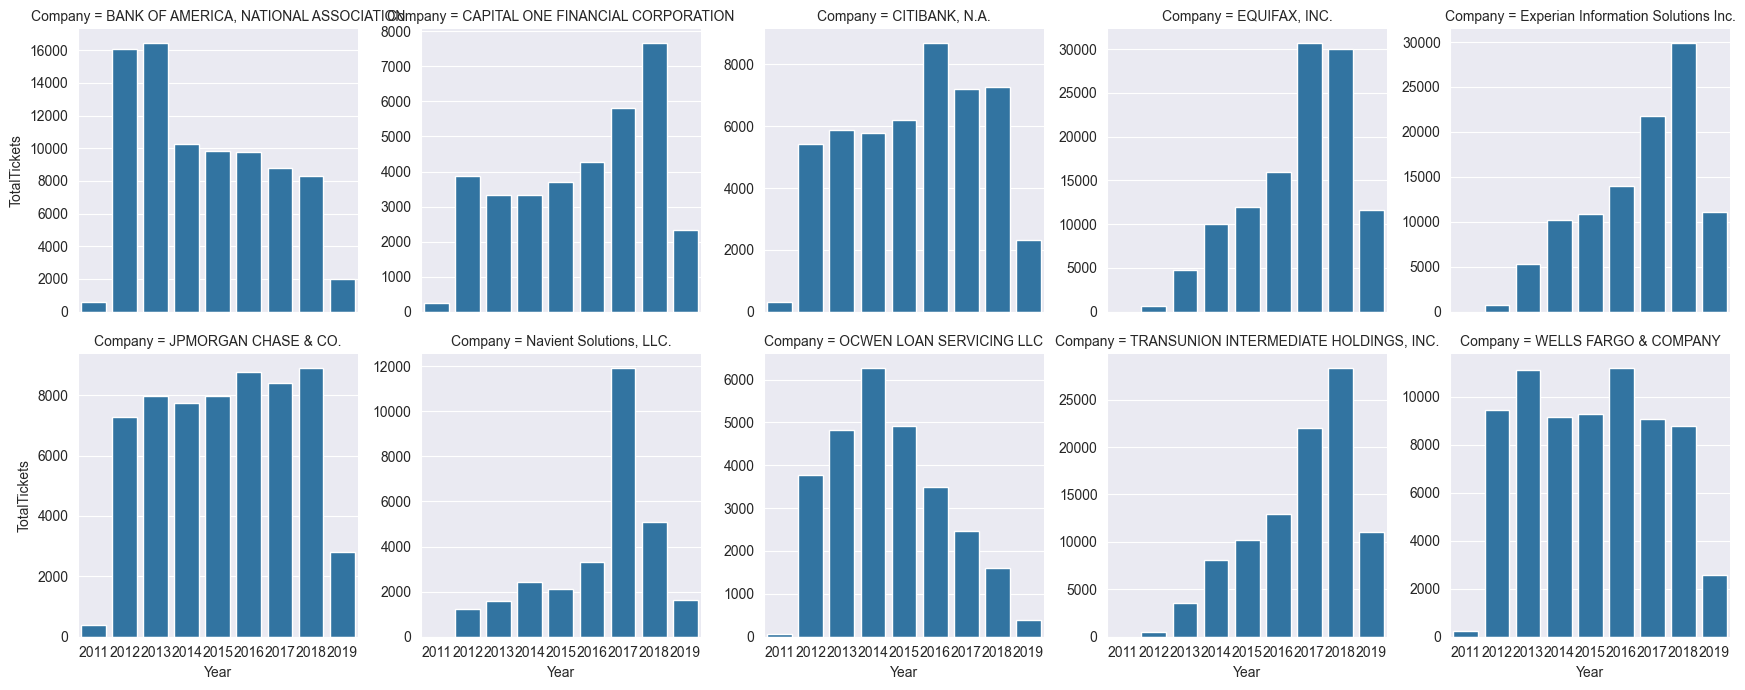

In [73]:
plot_bar_chart = sns.catplot(
    data=plot_df, kind='bar',
    x='Year', y='TotalTickets', col='Company',
    col_wrap=5, sharey=False, height=3.5
)

In [76]:
# df['Year'] = pd.to_datetime(df['Date received']).dt.year
# df['YearMonth'] = df['Date received'].dt.to_period('M').astype(str)
# df['Company'] = df['Company']
#  # uma linha == 1 ticket
# print(df['QtTickets'].count())

df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
df = df.dropna(subset=['Date received', 'Company'])

# create month timestamp (start of month) for ordering
df['YearMonth'] = df['Date received'].dt.to_period('M').dt.to_timestamp()
df['QtTickets'] = 1


In [79]:
monthly = (
    df.groupby(['Company', 'YearMonth'], as_index=False)
      .agg(MonthlyTickets=('QtTickets', 'sum'))
)
print("Monthly sample:")
print(monthly.head())
monthly_pivot = monthly.pivot(index='YearMonth', columns='Company', values='MonthlyTickets').fillna(0).astype(int)
print("\nPivot sample (first 5 months):")
print(monthly_pivot.head())


Monthly sample:
                                    Company  YearMonth  MonthlyTickets
0  (Former)Shapiro, Swertfeger & Hasty, LLP 2014-01-01               1
1  (Former)Shapiro, Swertfeger & Hasty, LLP 2014-11-01               1
2  (Former)Shapiro, Swertfeger & Hasty, LLP 2014-12-01               1
3  (Former)Shapiro, Swertfeger & Hasty, LLP 2015-08-01               1
4  (Former)Shapiro, Swertfeger & Hasty, LLP 2017-04-01               1

Pivot sample (first 5 months):
Company     (Former)Shapiro, Swertfeger & Hasty, LLP  \
YearMonth                                              
2011-12-01                                         0   
2012-01-01                                         0   
2012-02-01                                         0   
2012-03-01                                         0   
2012-04-01                                         0   

Company     1 STOP MONEY CENTERS, LLC  10 Cent Title Pawn Inc  \
YearMonth                                                       
201

In [81]:
top_n = 10
top_companies = (
    df.groupby('Company', as_index=False)
      .agg(Total=('QtTickets', 'sum'))
      .nlargest(top_n, 'Total')['Company']
      .tolist()
)
plot_df = monthly[monthly['Company'].isin(top_companies)].copy()


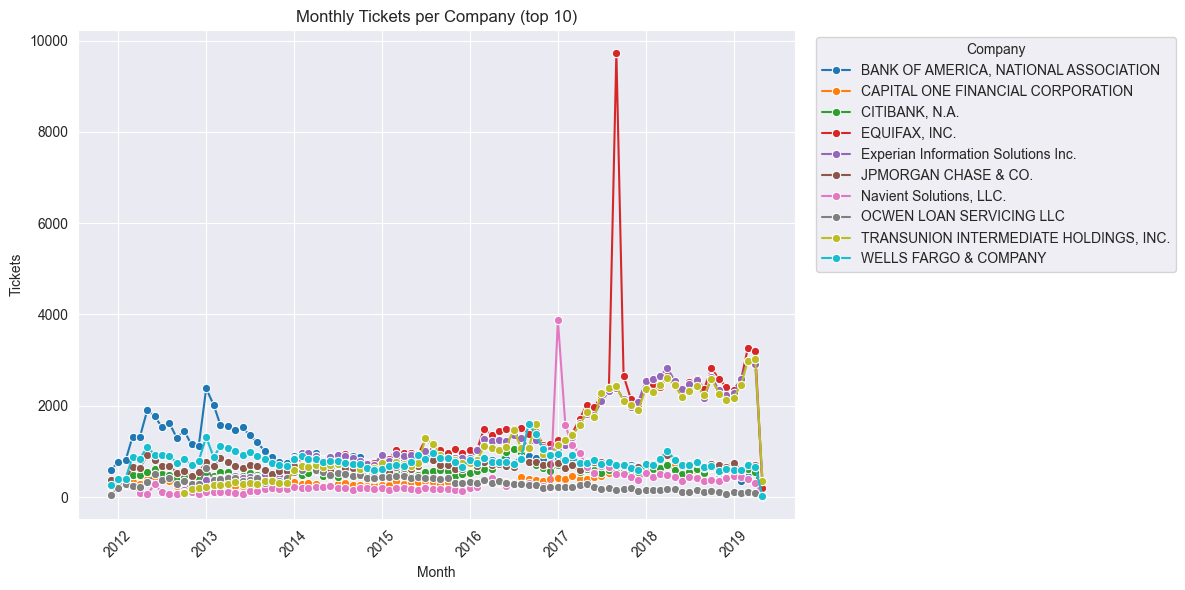

In [82]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='YearMonth', y='MonthlyTickets', hue='Company', marker='o')
plt.title(f'Monthly Tickets per Company (top {top_n})')
plt.xlabel('Month')
plt.ylabel('Tickets')
plt.xticks(rotation=45)
plt.legend(title='Company', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [83]:
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

In [144]:
CSV_PATH = "/home/ana/.cache/kagglehub/datasets/selener/consumer-complaint-database/versions/1/rows.csv"   # ajuste se necessário
DATE_COL = "Date received"
COMPANY_COL = "Company"
TOP_N = 10
FORECAST_PERIODS = 12        # prever 1 mês à frente
SEASONAL_PERIOD = 12

ERROR! Session/line number was not unique in database. History logging moved to new session 70
Selecionadas top 20 empresas.
Arquivo salvo: company_expected_increase_monthly.csv


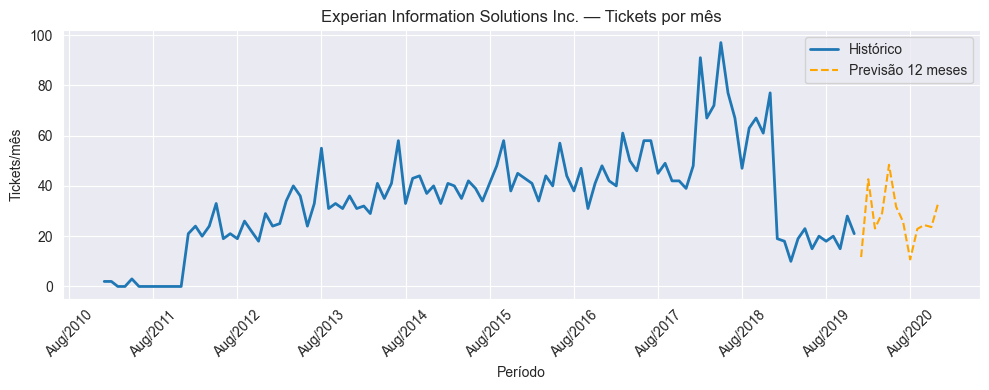

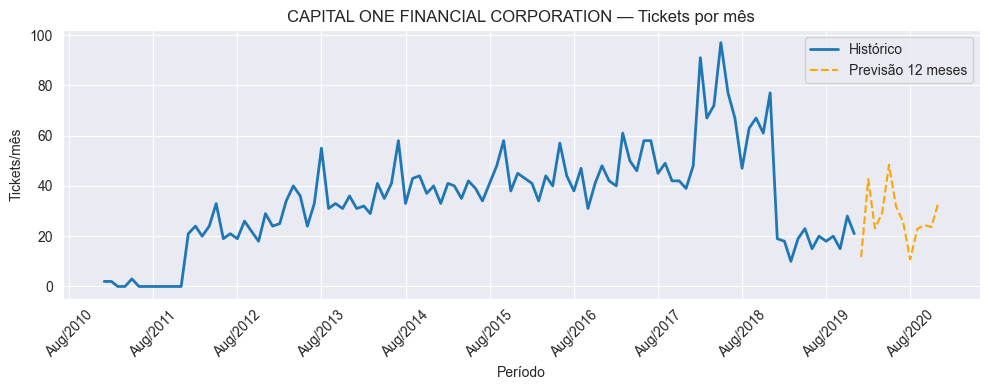

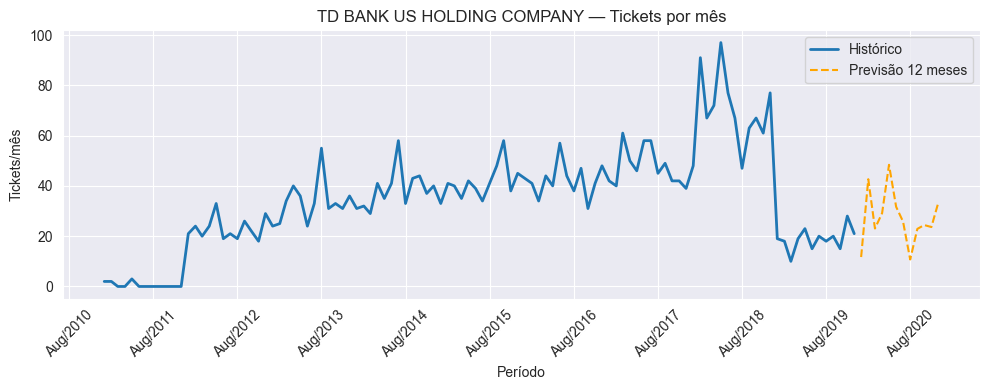

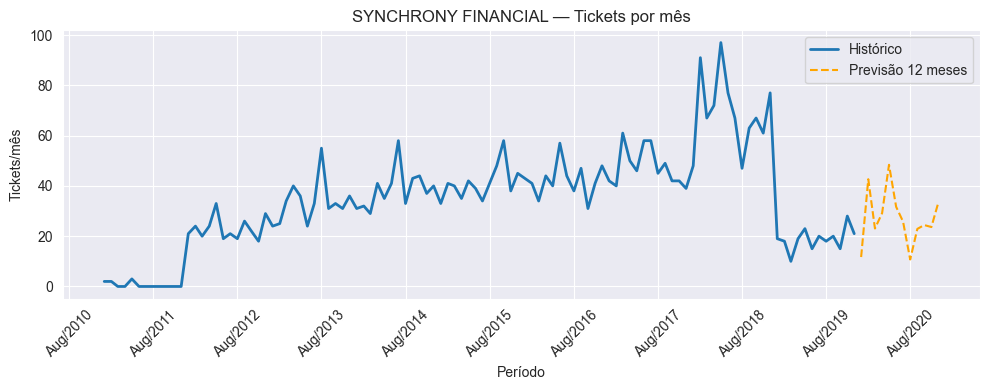

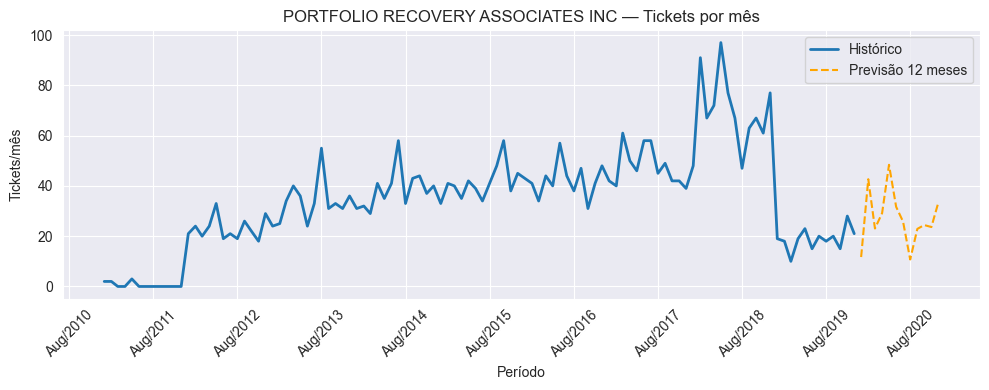

In [147]:
import matplotlib.dates as mdates
import numpy as np
df = pd.read_csv(
    CSV_PATH,
    usecols=[DATE_COL, COMPANY_COL],
    parse_dates=[DATE_COL],
    dayfirst=True,
    infer_datetime_format=True,
)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce", dayfirst=True)
df = df.dropna(subset=[DATE_COL, COMPANY_COL])
df[DATE_COL] = df[DATE_COL].astype("datetime64[ns]")

# Remove nulos
df = df.dropna(subset=[DATE_COL, COMPANY_COL])

# 2️⃣ Agregação mensal por empresa
df["YearMonth"] = df[DATE_COL].dt.to_period("M")
agg = df.groupby([COMPANY_COL, "YearMonth"]).size().reset_index(name="count")
agg["YearMonth"] = agg["YearMonth"].dt.to_timestamp()

# 3️⃣ Seleciona top empresas
totals = agg.groupby(COMPANY_COL)["count"].sum().sort_values(ascending=False)
top_companies = totals.head(TOP_N).index.tolist()
print(f"Selecionadas top {len(top_companies)} empresas.")

# Helper: criar série mensal contínua
def make_monthly_series(company_df, start, end):
    idx = pd.period_range(start=start, end=end, freq="M").to_timestamp()
    s = company_df.set_index("YearMonth")["count"].reindex(idx, fill_value=0)
    s.index.name = "YearMonth"
    return s

overall_start = agg["YearMonth"].min()
overall_end = agg["YearMonth"].max()

results = []

for comp in top_companies:
    comp_df = agg[agg[COMPANY_COL] == comp][["YearMonth", "count"]].copy()
    series = make_monthly_series(comp_df, overall_start, overall_end)

    # SARIMAX simples (sem auto_arima)
    try:
        model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,0,SEASONAL_PERIOD),
                        enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        forecast = res.get_forecast(steps=FORECAST_PERIODS).predicted_mean
        forecast_sum = forecast.sum()
    except Exception as e:
        forecast_sum = np.nan

    # baseline: média do mesmo mês em anos anteriores
    last_month = series.index[-1]
    target_month = last_month + pd.offsets.MonthEnd(1)
    same_months = [target_month - pd.DateOffset(years=i) for i in range(1,6)]
    baseline_vals = [series.loc[m] for m in same_months if m in series.index]
    baseline_mean = np.mean(baseline_vals) if baseline_vals else series.tail(3).mean()

    expected_increase = forecast_sum - baseline_mean
    pct_increase = (expected_increase / baseline_mean * 100) if baseline_mean>0 else np.nan

    results.append({
        "Company": comp,
        "ForecastNextMonth": float(forecast_sum),
        "BaselineMean": float(baseline_mean),
        "ExpectedIncrease": float(expected_increase),
        "PctIncrease": float(pct_increase)
    })

# 4️⃣ Resultados ordenados
res_df = pd.DataFrame(results).sort_values(by="ExpectedIncrease", ascending=False)
res_df.to_csv("company_expected_increase_monthly.csv", index=False)
print("Arquivo salvo: company_expected_increase_monthly.csv")
res_df.head(10)

# 5️⃣ Plot das top 5
for comp in res_df.head(5)["Company"]:
    # Forecast
    fc = res.get_forecast(steps=FORECAST_PERIODS).predicted_mean
    fc_index = pd.date_range(
        start=series.index[-1] + pd.offsets.MonthEnd(1),
        periods=FORECAST_PERIODS,
        freq='M'
    )

    plt.figure(figsize=(10,4))
    plt.plot(series.index, series.values, label="Histórico", linewidth=2)
    plt.plot(fc_index, fc, label=f"Previsão {FORECAST_PERIODS} meses", linestyle='--', color='orange')

    plt.title(f"{comp} — Tickets por mês")
    plt.ylabel("Tickets/mês")
    plt.xlabel("Período")

    ax = plt.gca()
    # Forçar ticks em cada mês
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
    plt.xticks(rotation=45)

    plt.legend()
    plt.tight_layout()
    plt.show()


In [159]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [162]:
CSV_PATH = "/home/ana/.cache/kagglehub/datasets/selener/consumer-complaint-database/versions/1/rows.csv"  # caminho do seu CSV
FORECAST_DAYS = 30                    # número de dias a prever
TOP_N_COMPANIES = 10                  # quantas empresas quer estudar

In [173]:
df = pd.read_csv(CSV_PATH)

# Converte a coluna de data manualmente (seguro contra formatos inconsistentes)
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce', dayfirst=True)

# Remove registros sem data ou empresa
df = df.dropna(subset=['Date received', 'Company'])

# Cria coluna com a contagem de tickets
df['QtTickets'] = 1

# Cria coluna de período (Ano-Mês)
df['YearMonth'] = df['Date received'].dt.to_period('M')

In [174]:
monthly = (
    df.groupby(['Company', 'YearMonth'])['QtTickets']
    .sum()
    .reset_index()
)
monthly['YearMonth'] = monthly['YearMonth'].dt.to_timestamp()


In [175]:
top_companies = (
    df.groupby('Company', as_index=False)
      .agg(Total=('QtTickets', 'sum'))
      .nlargest(top_n, 'Total')['Company']
      .tolist()
)
plot_df = monthly[monthly['Company'].isin(top_companies)].copy()

monthly_top = monthly[monthly['Company'].isin(top_companies)]
monthly_top['year'] = monthly_top['YearMonth'].dt.year
monthly_top['month'] = monthly_top['YearMonth'].dt.month
print(top_companies)

['EQUIFAX, INC.', 'Experian Information Solutions Inc.', 'TRANSUNION INTERMEDIATE HOLDINGS, INC.', 'BANK OF AMERICA, NATIONAL ASSOCIATION', 'WELLS FARGO & COMPANY', 'JPMORGAN CHASE & CO.', 'CITIBANK, N.A.', 'CAPITAL ONE FINANCIAL CORPORATION', 'OCWEN LOAN SERVICING LLC', 'Navient Solutions, LLC.']


In [176]:
results = {}

for company, data in monthly_top.groupby('Company'):
    if len(data) < 6:
        continue

    X = data[['year', 'month']]
    y = data['QtTickets']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)

    results[company] = {
        "model": model,
        "mae": mae,
        "data": data
    }


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22
[LightGBM] [Info] Number of data points in the train set: 86, number of used features: 2
[LightGBM] [Info] Start training from score 334.290698
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [177]:
forecast_summary = []

for company, res in results.items():
    model = res['model']
    data = res['data'].copy()

    last_date = data['YearMonth'].max()
    future_dates = pd.date_range(
        start=last_date + pd.offsets.MonthEnd(1),
        periods=int(FORECAST_DAYS / 30),
        freq='M'
    )
    future_df = pd.DataFrame({
        'year': future_dates.year,
        'month': future_dates.month
    })
    pred = model.predict(future_df)

    growth = (pred[-1] - data['QtTickets'].iloc[-1]) / data['QtTickets'].iloc[-1] * 100
    forecast_summary.append((company, growth, pred[-1], res['mae']))

forecast_df = pd.DataFrame(forecast_summary, columns=['Company', 'Growth (%)', 'Predicted Tickets', 'MAE'])
forecast_df = forecast_df.sort_values(by='Growth (%)', ascending=False)

print("\n🔝 Top 10 empresas com maior previsão de aumento de tickets:")
display(forecast_df)


🔝 Top 10 empresas com maior previsão de aumento de tickets:


,Company,Growth (%),Predicted Tickets,MAE
7,OCWEN LOAN SERVICING LLC,583.882458,95.743544,58.186195
0,"BANK OF AMERICA, NATIONAL ASSOCIATION",358.248181,307.026282,142.806550
6,"Navient Solutions, LLC.",248.096854,198.415207,94.642773
9,WELLS FARGO & COMPANY,245.769851,328.481359,147.338279
2,"CITIBANK, N.A.",203.404673,254.859925,108.264410
5,JPMORGAN CHASE & CO.,168.769413,279.520189,114.447266
3,"EQUIFAX, INC.",139.643616,1056.828348,382.056963
1,CAPITAL ONE FINANCIAL CORPORATION,89.837801,167.057265,89.132383
8,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",43.467530,595.390249,283.453792
4,Experian Information Solutions Inc.,36.365212,604.097891,308.051281


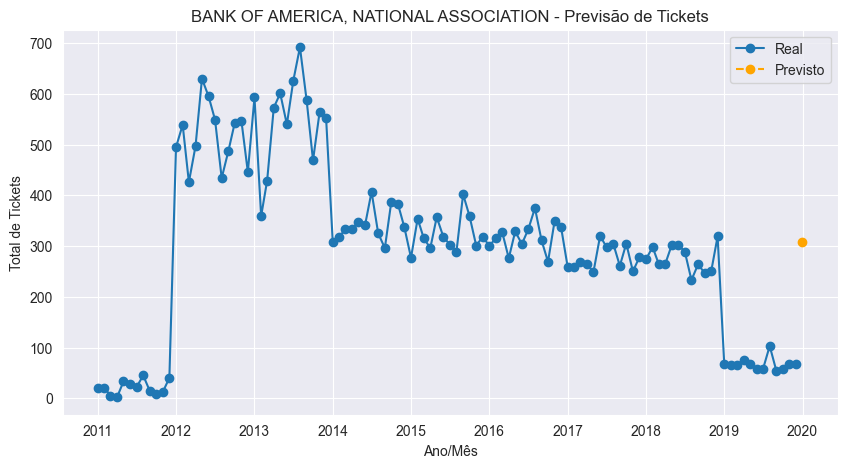

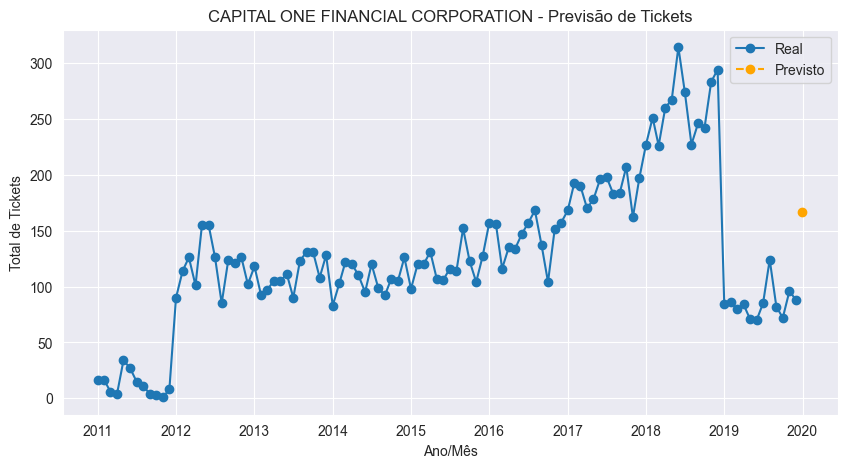

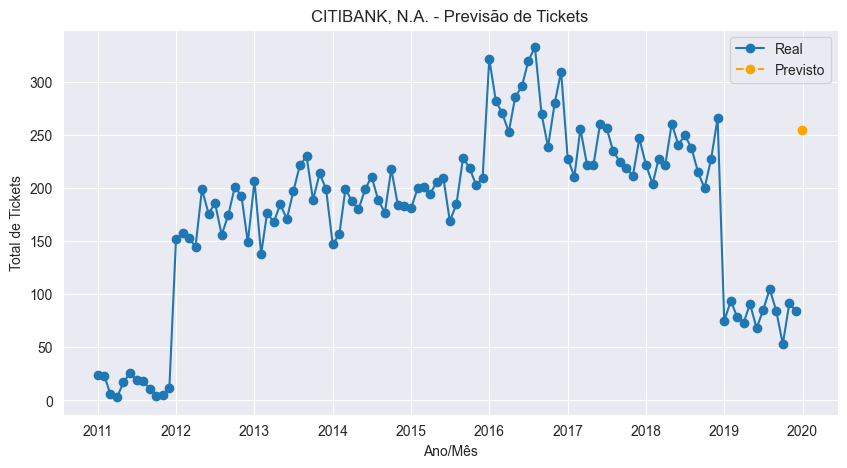

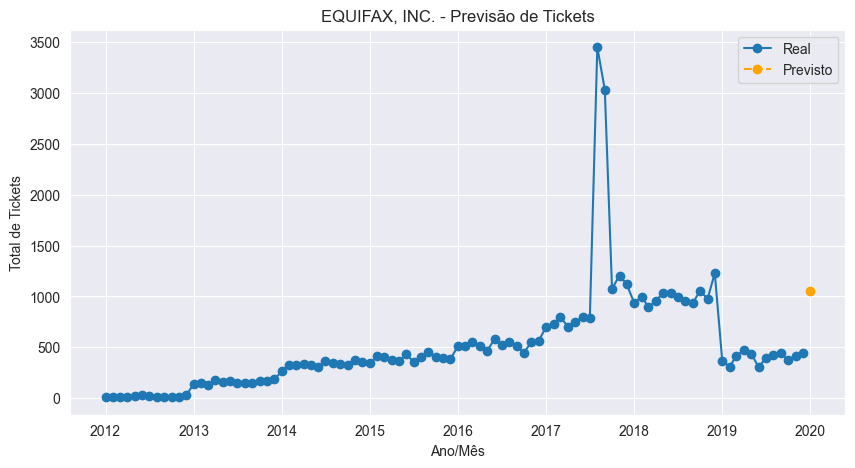

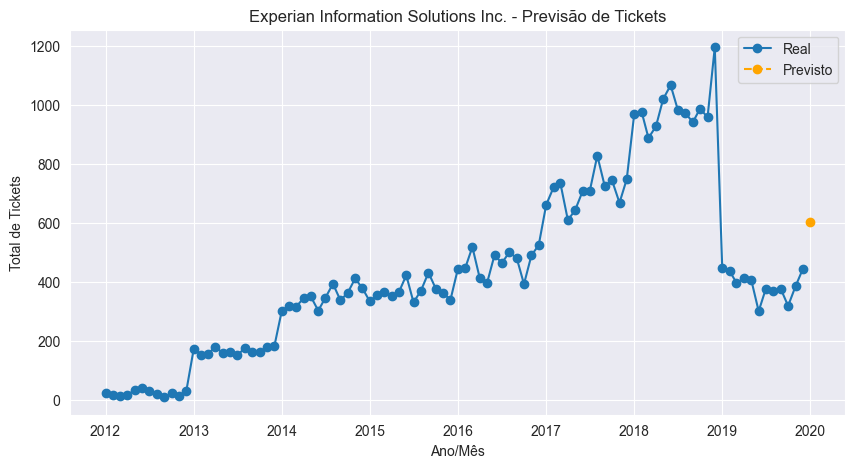

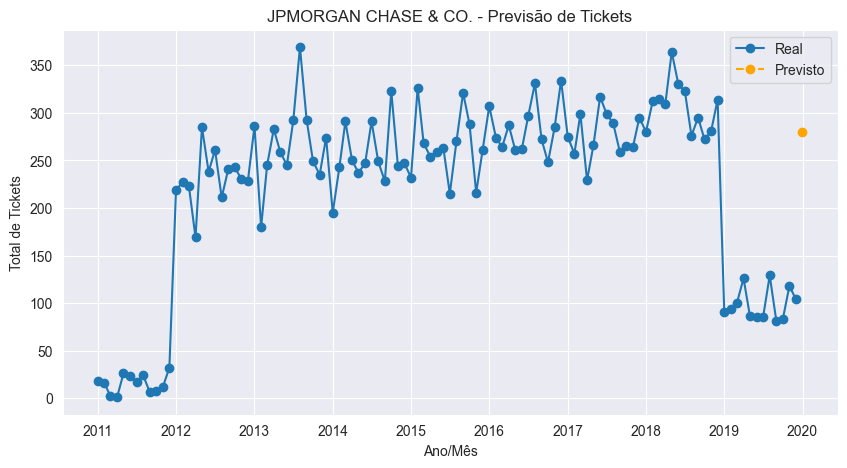

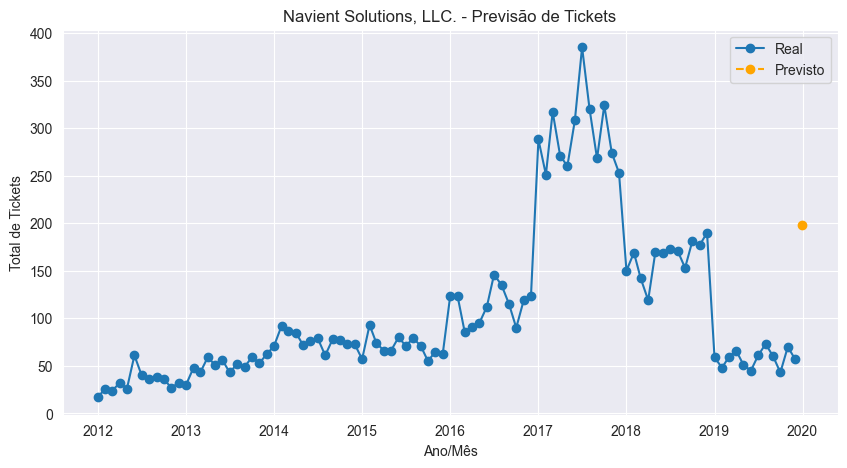

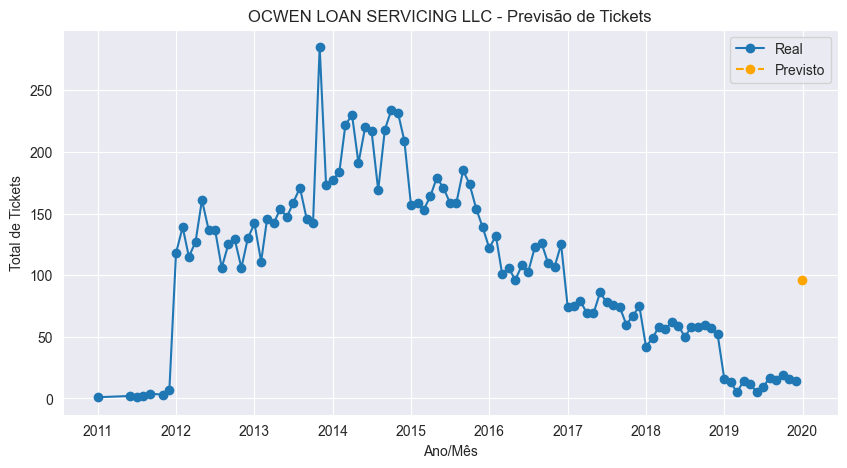

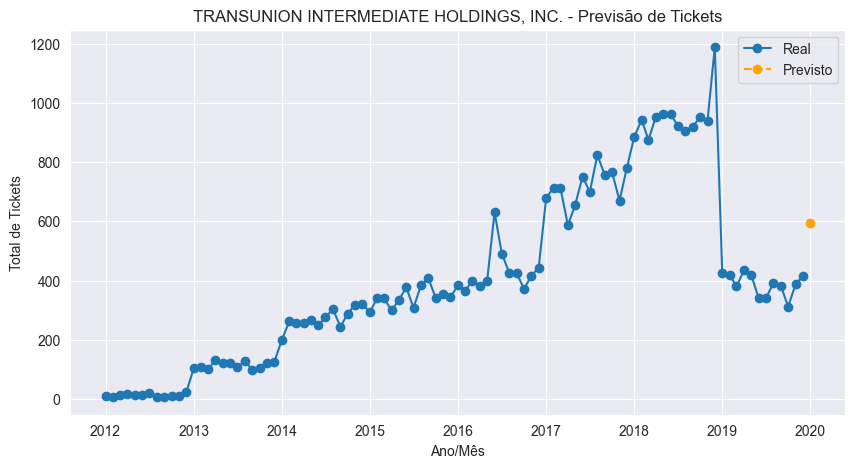

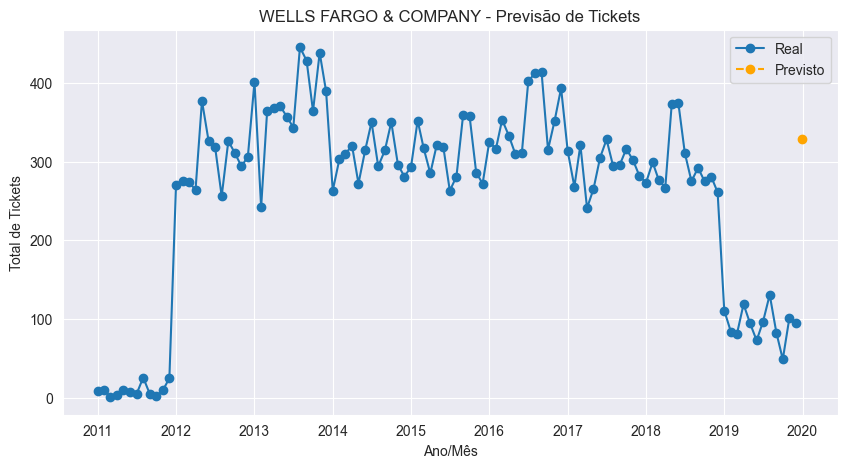

In [183]:
for company, res in results.items():
    data = res['data'].copy()
    model = res['model']
    last_date = data['YearMonth'].max()

    future_dates = pd.date_range(
        start=last_date + pd.offsets.MonthEnd(1),
        periods=int(FORECAST_DAYS / 30),
        freq='M'
    )
    future_df = pd.DataFrame({
        'year': future_dates.year,
        'month': future_dates.month
    })
    future_pred = model.predict(future_df)

    plt.figure(figsize=(10, 5))
    plt.plot(data['YearMonth'], data['QtTickets'], label='Real', marker='o')
    plt.plot(future_dates, future_pred, label='Previsto', linestyle='--', color='orange', marker='o')
    plt.title(f"{company} - Previsão de Tickets")
    plt.xlabel("Ano/Mês")
    plt.ylabel("Total de Tickets")
    plt.legend()
    plt.grid(True)
    plt.show()